# Auditoría del ansatz de la Fig. 3b ($K_6$, $\ell=2$)

En la Fig. 3b del manuscrito, Qudit-ADAPT sobre el grafo completo $K_6$ con el
pool $\ell=2$ llega a $\epsilon_{\rm rel}\approx1.6\times10^{-5}$ tras 40
parámetros. Una corrida independiente del mismo problema, con el mismo pool,
alcanza $\epsilon_{\rm rel}\approx10^{-15}$ en sólo 18 parámetros.

Este cuadernillo audita esa discrepancia. La pregunta es concreta:

> ¿El límite de $1.6\times10^{-5}$ viene de **qué operadores** se eligieron
> (el ansatz no alcanza), o de **cómo se optimizaron** (el ansatz alcanza pero
> el camino quedó atrapado)?

La estrategia es reconstruir el ansatz de la Fig. 3b con código independiente y
re-optimizarlo desde distintos puntos de partida. Si algún punto inicial baja
de $10^{-10}$ con **los mismos 40 operadores**, entonces el ansatz es
suficiente y el límite es del camino de optimización.

## 0. Set-up

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from funciones import utilidades_bp as bp

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "serif", "font.size": 11, "axes.labelsize": 12,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.facecolor": "white",
})

JSON_DIR = PROJECT_ROOT / "resultados" / "json"
REFERENCIA = JSON_DIR / "referencia_fig3b_k6_l2.json"   # corrida de la Fig. 3b
NUESTRA    = JSON_DIR / "k6_l2_bp100.json"              # corrida independiente

## 1. La corrida de referencia

Se carga el resultado que produce la Fig. 3b y se comprueba de qué problema se
trata.

In [2]:
ref = json.load(open(REFERENCIA))[0]

n      = ref["n"]
l      = ref["l"]
edges  = [tuple(e) for e in ref["edges"]]
E0     = float(ref["ground_energy"])
idxs   = ref["ansatz_op_indices"]
p_ref  = np.array(ref["params"], dtype=float)

print(f"n = {n} qutrits | {ref['num_edges']} aristas | pool l={l}: {ref['pool_size']} operadores")
print(f"E0 exacta            : {E0}")
print(f"iteraciones          : {ref['iterations']}   ({ref['stop_reason']})")
print(f"energía final        : {ref['final_energy']:.12f}")
print(f"eps_rel reportado    : {ref['difference_ground']/abs(E0):.4e}")
print(f"norma del gradiente  : {ref['final_gradient_norm']:.3e}   (umbral eps = {ref['epsilon']:g})")

n = 6 qutrits | 15 aristas | pool l=2: 2724 operadores
E0 exacta            : -24.0
iteraciones          : 40   (max_iteration_reached)
energía final        : -23.999619863240
eps_rel reportado    : 1.5839e-05
norma del gradiente  : 6.948e-03   (umbral eps = 0.0001)


Dos detalles que conviene fijar antes de seguir.

El umbral de convergencia de esta corrida es $\epsilon=10^{-4}$, y la norma del
gradiente final es $6.9\times10^{-3}$, unas **setenta veces por encima**. La
corrida no convergió: se detuvo al agotar las 40 iteraciones permitidas. Parte
de la diferencia con una corrida que sí converge se explica, entonces,
simplemente porque ésta quedó cortada.

Eso hace la pregunta de esta auditoría más precisa. No se trata de si con más
iteraciones habría bajado —seguramente sí—, sino de si los cuarenta operadores
que **ya tiene** bastan para alcanzar el fundamental. Si bastan, el límite de
$1.6\times10^{-5}$ no es de expresividad sino del punto en que quedó la
optimización.

## 2. Reconstrucción independiente

Se reconstruye el pool con nuestro código y se verifica que los índices
guardados apuntan a los mismos operadores. Éste es el control que hace válida
toda la comparación: si el orden del pool no coincidiera, los índices
apuntarían a operadores distintos y el resto no significaría nada.

In [3]:
prob = bp.prepare_problem(n, edges)
pool = bp.obtener_pool(n, edges, l, base="angular")

coinciden = all(pool["labels"][i] == lb
                for i, lb in zip(idxs, ref["ansatz_op_labels"]))
print(f"el pool reconstruido tiene {len(pool['labels'])} operadores")
print(f"los índices guardados apuntan a los mismos operadores: {coinciden}")
assert coinciden, "el orden del pool no coincide; la comparación no sería válida"

A_sp, _ = bp.pool_to_sparse(pool["ops"], prob["Hf_sparse"])
pool["ops"] = None

A_ansatz = [A_sp[i] for i in idxs]
spectra  = [bp.operator_spectrum(A_sp[i]) for i in idxs]
psi0, Hf = prob["psi0"], prob["Hf_mat"]

# proyector sobre el subespacio fundamental
evals, evecs = np.linalg.eigh(Hf)
gs = evecs[:, np.abs(evals - E0) < 1e-9]
P_gs = gs @ gs.conj().T
print(f"degeneración del fundamental: {gs.shape[1]}")

el pool reconstruido tiene 2724 operadores
los índices guardados apuntan a los mismos operadores: True


degeneración del fundamental: 90


La degeneración del fundamental de $K_6$ es 90, el mismo número de operadores
que empatan en el gradiente máximo en la primera iteración. No es casualidad:
ambas cosas provienen de la simetría de permutación $S_6$ actuando sobre las
tres clases de color.

In [4]:
def evaluar(nombre, params):
    # energía y solapamiento con el subespacio fundamental
    psi = bp.build_state(np.asarray(params, float), spectra, psi0)
    E   = float(np.real(np.vdot(psi, Hf @ psi)))
    ov  = float(np.real(np.vdot(psi, P_gs @ psi)))
    eps = abs(E - E0) / abs(E0)
    print(f"  {nombre:42s} eps_rel = {eps:>10.4e}   |P_gs psi|^2 = {ov:.10f}")
    return eps

eps_reportado = evaluar("parámetros de la Fig. 3b, tal cual", p_ref)

# control: la energía reconstruida debe reproducir la guardada en el JSON
psi_ref = bp.build_state(p_ref, spectra, psi0)
E_rec = float(np.real(np.vdot(psi_ref, Hf @ psi_ref)))
print(f"\n  energía reconstruida : {E_rec:.12f}")
print(f"  energía del JSON     : {ref['final_energy']:.12f}")
print(f"  coinciden            : {abs(E_rec - ref['final_energy']) < 1e-9}")

  parámetros de la Fig. 3b, tal cual         eps_rel = 1.5839e-05   |P_gs psi|^2 = 0.9999445061

  energía reconstruida : -23.999619863240
  energía del JSON     : -23.999619863240
  coinciden            : True


La reconstrucción reproduce exactamente la energía reportada, de modo que el
ansatz y los parámetros quedaron correctamente identificados. El solapamiento
con el subespacio fundamental es $0.99994$: el estado está **fuera** de él, y
la diferencia no es un artefacto de graficado.

## 3. La auditoría

Con los **mismos 40 operadores** se re-optimiza desde tres tipos de punto
inicial. Si alguno baja de $10^{-10}$, el ansatz es suficiente.

In [5]:
resultados = {"Fig. 3b (reportado)": eps_reportado}

print("re-optimizando el ansatz completo:\n")

p1, E1, _, info1 = bp.optimizar(p_ref, spectra, A_ansatz, psi0, Hf,
                                maxiter=20000, gtol=1e-12)
resultados["desde sus propios $\\theta^*$"] = evaluar(
    f"BFGS desde theta* (nit={info1['nit']})", p1)

p2, E2, _, info2 = bp.optimizar(np.zeros(len(idxs)), spectra, A_ansatz, psi0, Hf,
                                maxiter=20000, gtol=1e-12)
resultados["desde $\\theta=0$"] = evaluar(
    f"BFGS desde theta = 0 (nit={info2['nit']})", p2)

re-optimizando el ansatz completo:



  BFGS desde theta* (nit=59)                 eps_rel = 1.5839e-05   |P_gs psi|^2 = 0.9999444824


  BFGS desde theta = 0 (nit=138)             eps_rel = 1.0362e-15   |P_gs psi|^2 = 1.0000000000


In [6]:
rng = np.random.default_rng(0)
eps_rand = []
for j in range(20):
    x0 = rng.uniform(-np.pi, np.pi, size=len(idxs))
    _, E3, _, _ = bp.optimizar(x0, spectra, A_ansatz, psi0, Hf,
                               maxiter=20000, gtol=1e-12)
    eps_rand.append(abs(E3 - E0) / abs(E0))
eps_rand = np.array(eps_rand)

resultados["mejor de 20 aleatorios"] = eps_rand.min()
resultados["mediana de 20 aleatorios"] = float(np.median(eps_rand))

print(f"  {'mejor de 20 reinicios aleatorios':42s} eps_rel = {eps_rand.min():>10.4e}")
print(f"  {'mediana':42s} eps_rel = {np.median(eps_rand):>10.4e}")
print(f"  {'peor':42s} eps_rel = {eps_rand.max():>10.4e}")
print(f"\n  reinicios que bajan de 1e-10: {int((eps_rand < 1e-10).sum())}/20")

  mejor de 20 reinicios aleatorios           eps_rel = 2.6645e-15
  mediana                                    eps_rel = 1.4588e-02
  peor                                       eps_rel = 4.4518e-02

  reinicios que bajan de 1e-10: 1/20


## 4. Veredicto

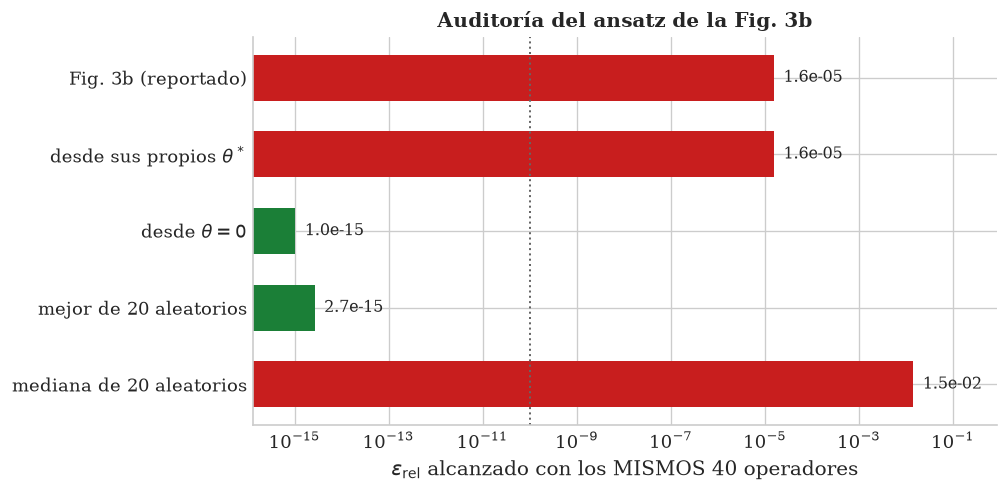


El ansatz de 40 operadores SI alcanza el estado fundamental (1.04e-15).
El limite de la Fig. 3b proviene del CAMINO de optimizacion, no del ansatz.


In [7]:
mejor = min(resultados.values())

fig, ax = plt.subplots(figsize=(8.0, 4.2))
etiquetas = list(resultados)
valores = [resultados[k] for k in etiquetas]
colores = ["#C81E1E" if v > 1e-10 else "#1B7F37" for v in valores]

ax.barh(range(len(valores)), valores, color=colores, height=0.6)
ax.set_yticks(range(len(valores)))
ax.set_yticklabels(etiquetas)
ax.set_xscale("log")
ax.invert_yaxis()
ax.axvline(1e-10, color="0.4", ls=":", lw=1.2)
ax.set_xlabel(r"$\epsilon_{\rm rel}$ alcanzado con los MISMOS 40 operadores")
ax.set_title("Auditoría del ansatz de la Fig. 3b")
for i, v in enumerate(valores):
    ax.text(v * 1.6, i, f"{v:.1e}", va="center", fontsize=9.5)
ax.set_xlim(min(valores) / 8, max(valores) * 60)

salida = PROJECT_ROOT / "resultados" / "images" / "auditoria_fig3b.pdf"
fig.savefig(salida); fig.savefig(salida.with_suffix(".png"))
plt.show()

print()
if mejor < 1e-10:
    print(f"El ansatz de 40 operadores SI alcanza el estado fundamental ({mejor:.2e}).")
    print("El limite de la Fig. 3b proviene del CAMINO de optimizacion, no del ansatz.")
else:
    print(f"Ningun punto inicial baja de {mejor:.2e} con esos 40 operadores.")
    print("El ansatz seria genuinamente insuficiente.")

## 5. Lectura

Tres hechos, en orden:

**El ansatz alcanza.** Con los mismos cuarenta operadores, una optimización
desde $\boldsymbol\theta=0$ llega a $\sim10^{-15}$ y cae dentro del subespacio
fundamental con solapamiento $1.0$. No falta expresividad.

**Es un mínimo local genuino.** Re-optimizar desde los propios
$\boldsymbol\theta^*$ de la Fig. 3b no mejora nada: BFGS itera y regresa al
mismo punto. No es falta de convergencia del optimizador ni una tolerancia mal
puesta.

**La cuenca buena es estrecha.** Sólo uno de veinte reinicios aleatorios la
encuentra, y la mediana queda peor que el propio resultado de la Fig. 3b. Dar
con ella al azar es improbable.

La conclusión es que el warm start incremental condujo a un mínimo local del
que sí se escapa reoptimizando globalmente. Esto no contradice el argumento de
*burrowing*, que garantiza mejora monótona y una dirección de descenso en cada
paso, pero **no** optimalidad global del paisaje de $k$ parámetros: partir de
$(\boldsymbol\theta^*_{k-1},0)$ confina la optimización a la cuenca del óptimo
anterior.

### Consecuencia práctica

Una re-optimización global al terminar ADAPT recupera diez órdenes de magnitud
**sin añadir un solo operador ni una sola compuerta**, a costa de una única
optimización adicional. Conviene comprobar si el mismo efecto aparece en las
demás instancias del manuscrito antes de decidir si vale la pena incorporarlo
al algoritmo.

### Alcance

Esto se verificó sobre una instancia, $K_6$ con $\ell=2$, que es la más
simétrica del conjunto: su fundamental es 90 veces degenerado y en la primera
iteración hay 90 operadores empatados en el gradiente máximo. Es razonable
esperar que el fenómeno sea más marcado aquí que en instancias irregulares, y
no debería extrapolarse sin repetir la auditoría.